In [1]:
from pathlib import Path
import hashlib, importlib.util, os, runpy, sys, time, urllib.request, urllib.error

RUN_STARTED = time.perf_counter()
COURSE_REVISION = "fe0c0204e6076a7ac2139b7336485a097343fb8a"
MANIFEST_SHA256 = "86d15e813caf833b7d86512808176388d4123dc3c01c6525ee849a76e8322c59"
SETUP_SHA256 = "79608f8f9559d9e6eb09d51ee541ee12d7e9262ac57d1ca3a948c8ecb14f0f35"
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content/tamweel") if IN_COLAB else Path(os.environ.get("TAMWEEL_PROJECT_DIR", ".")).resolve()
setup_path = ROOT / "scripts/setup_colab.py"
setup_path.parent.mkdir(parents=True, exist_ok=True)
if not setup_path.exists() or hashlib.sha256(setup_path.read_bytes()).hexdigest() != SETUP_SHA256:
    setup_url = f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{COURSE_REVISION}/scripts/setup_colab.py"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(setup_url, timeout=45) as response:
                setup_bytes = response.read(200000)
            if hashlib.sha256(setup_bytes).hexdigest() != SETUP_SHA256:
                raise ValueError("Setup checksum mismatch. Reopen the released notebook.")
            setup_path.write_bytes(setup_bytes)
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise RuntimeError("Download unavailable. Retry setup or upload the unchanged project files; see READINESS_GUIDE.")
            time.sleep(attempt + 1)
environment = runpy.run_path(str(setup_path))["prepare"](ROOT, COURSE_REVISION, MANIFEST_SHA256)
FAST_MODE, FULL_MODE, SEED, N_JOBS = True, False, 211, 2

from setup_colab import fetch_verified
LAB_REVISION = "c8344f6b19b26dcbce3dcfc671b746c59bf55895"
LAB_SHA256 = "2a968ba9e738cc5e3dae12077e576fdb40ec6ec64230613e445bbc7884e7e1ba"
fetch_verified(
    f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{LAB_REVISION}/scripts/day1_lab.py",
    ROOT / "scripts/day1_lab.py", LAB_SHA256)
print("Day 1 setup verified | إعداد اليوم الأول جاهز")

Package                 Version
numpy                   2.1.3
pandas                  2.2.3
scipy                   1.16.3
scikit-learn            1.6.1
matplotlib              3.10.0
xgboost                 3.4.1
lightgbm                4.6.0
shap                    0.52.0
numba                   0.61.2
optuna                  4.5.0
Python 3.13.15 | CPU | seed=211 | n_jobs=2 | FAST_MODE=True
Verified course files. Next: run the data and compatibility checks.
Day 1 setup verified | إعداد اليوم الأول جاهز


In [3]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import roc_curve, precision_recall_curve
from data_checks import load_course_data
from day1_lab import (LabConfig, MODEL_NAMES, make_splits, select_tree_count,
                      fit_model, compare_models, learner_checkpoint, config_dict)

warnings.filterwarnings("ignore", message="scipy.optimize:.*disp.*", category=DeprecationWarning)
frames, contract, data_summary = load_course_data(ROOT)
train = frames["train"]
FAST_MODE, FULL_MODE = True, False  # Choose exactly one mode.
assert FAST_MODE != FULL_MODE, "Choose exactly one mode."
config = LabConfig(max_trees=300 if FAST_MODE else 900)
X, y, splits = make_splits(train, contract, seed=config.seed)
ARTIFACTS = ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
display(pd.DataFrame({"rows": [len(train)], "predictors": [X.shape[1]],
                      "positive_rate": [y.mean()], "missing_cells": [int(X.isna().sum().sum())]}))
display(train[["application_id", "income_sar", "bureau_score", contract["target"]["name"]]].head(3))

,rows,predictors,positive_rate,missing_cells
0,10000,22,0.0789,766


,application_id,income_sar,bureau_score,default_within_90d
0,TR-001121,8938.11,584.0,0
1,TR-002836,16995.65,652.0,0
2,TR-005579,8353.27,734.0,0


In [4]:
development, comparison = splits["development"], splits["comparison"]
inner_fit, inner_stop = splits["inner_fit"], splits["inner_stop"]
assert not (set(development) & set(comparison))
assert not (set(inner_fit) & set(inner_stop))
split_table = pd.DataFrame([
    {"role": role, "rows": len(index), "positive_rate": y.loc[index].mean()}
    for role, index in splits.items()
])
shared_customers = len(set(train.loc[development, "customer_id"]) & set(train.loc[comparison, "customer_id"]))
display(split_table)
print(f"Customers shared across development/comparison: {shared_customers} — revisit on Day 2")
models, timings, selections = {}, {}, {}

,role,rows,positive_rate
0,development,8000,0.078875
1,comparison,2000,0.079000
2,inner_fit,6000,0.078833
3,inner_stop,2000,0.079000


Customers shared across development/comparison: 1226 — revisit on Day 2


In [5]:
name = "Logistic Regression"
models[name], timings[name] = fit_model(name, X.loc[development], y.loc[development], config)
print(f"Baseline fitted on {len(development):,} rows in {timings[name]['train_seconds']:.3f} s")

Baseline fitted on 8,000 rows in 0.037 s


In [6]:
for name in ("XGBoost", "LightGBM"):
    selections[name] = select_tree_count(
        name, X.loc[inner_fit], y.loc[inner_fit], X.loc[inner_stop], y.loc[inner_stop], config)
    models[name], timings[name] = fit_model(
        name, X.loc[development], y.loc[development], config, selections[name])
    print(f"{name}: {selections[name]['selected_trees']} selected trees; "
          f"{selections[name]['rounds_evaluated']} evaluated rounds; "
          f"{timings[name]['train_seconds']:.3f} s including selection + refit")
    if selections[name]["hit_tree_budget"]:
        print("Tree budget reached: record this limitation before considering FULL_MODE.")

XGBoost: 61 selected trees; 91 evaluated rounds; 0.245 s including selection + refit
LightGBM: 41 selected trees; 71 evaluated rounds; 0.221 s including selection + refit


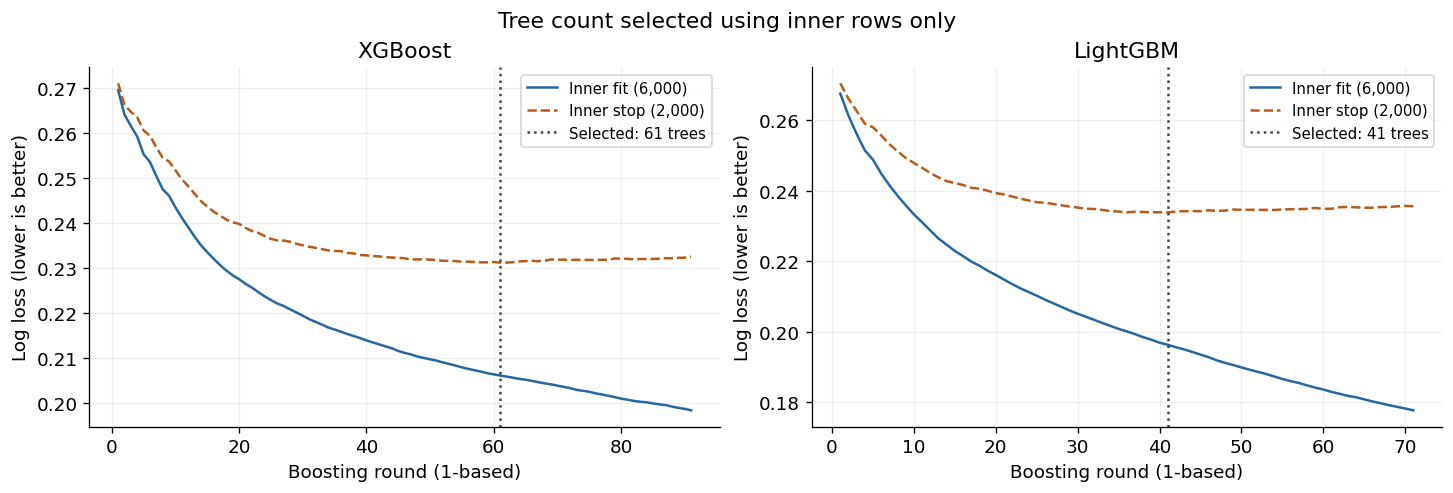

In [7]:
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})
colors = {"Logistic Regression": "#2667A0", "XGBoost": "#BA5A17", "LightGBM": "#18816A"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, (name, result) in zip(axes, selections.items()):
    rounds = np.arange(1, len(result["curves"]["fit"]) + 1)
    ax.plot(rounds, result["curves"]["fit"], label="Inner fit (6,000)", color="#2667A0")
    ax.plot(rounds, result["curves"]["stop"], label="Inner stop (2,000)", color="#BA5A17", linestyle="--")
    ax.axvline(result["selected_trees"], color="#444444", linestyle=":",
               label=f"Selected: {result['selected_trees']} trees")
    ax.set(title=name, xlabel="Boosting round (1-based)", ylabel="Log loss (lower is better)")
    ax.legend(fontsize=9)
fig.suptitle("Tree count selected using inner rows only")
fig.savefig(ARTIFACTS / "day1_learning_curves.png", dpi=160)
plt.show()

In [8]:
comparison_table, probabilities = compare_models(
    models, timings, selections, X.loc[comparison], y.loc[comparison])
comparison_table["selected_trees"] = comparison_table["selected_trees"].astype("Int64")
display(comparison_table[["model", "roc_auc", "average_precision", "train_seconds",
                          "selected_trees", "comparison_rows", "positive_rate"]].round(4))
comparison_table.to_csv(ARTIFACTS / "day1_model_comparison.csv", index=False)
prediction_export = train.loc[comparison, ["application_id", "default_within_90d"]].join(probabilities)
prediction_export.to_csv(ARTIFACTS / "day1_comparison_predictions.csv", index=False)
assert len(comparison_table) == 3
assert comparison_table[["roc_auc", "average_precision", "train_seconds"]].notna().all().all()
print("TECHNICAL_READY — three models compared; your interpretation is still required.")

,model,roc_auc,average_precision,train_seconds,selected_trees,comparison_rows,positive_rate
0,Logistic Regression,0.8213,0.3258,0.0375,<NA>,2000,0.079
1,XGBoost,0.8124,0.3338,0.2450,61,2000,0.079
2,LightGBM,0.8138,0.3248,0.2209,41,2000,0.079


TECHNICAL_READY — three models compared; your interpretation is still required.


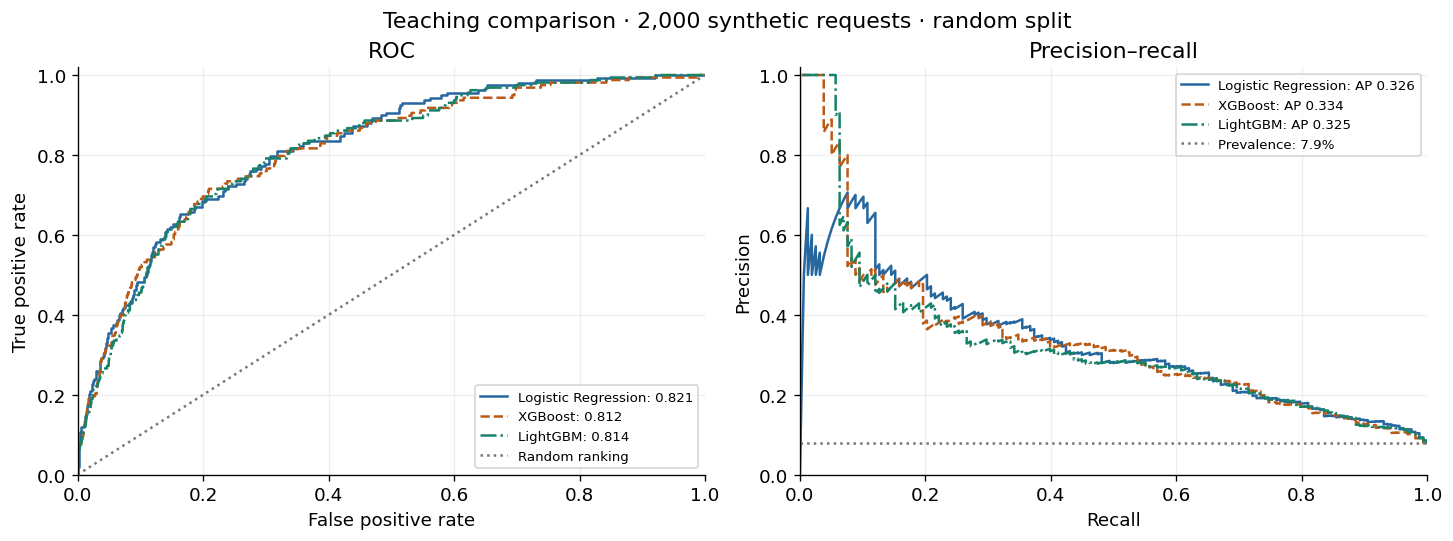

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
styles = ["-", "--", "-."]
for name, style in zip(MODEL_NAMES, styles):
    fpr, tpr, _ = roc_curve(y.loc[comparison], probabilities[name])
    precision, recall, _ = precision_recall_curve(y.loc[comparison], probabilities[name])
    row = comparison_table.set_index("model").loc[name]
    axes[0].plot(fpr, tpr, color=colors[name], linestyle=style, label=f"{name}: {row.roc_auc:.3f}")
    axes[1].plot(recall, precision, color=colors[name], linestyle=style, label=f"{name}: AP {row.average_precision:.3f}")
axes[0].plot([0, 1], [0, 1], color="#777777", linestyle=":", label="Random ranking")
axes[1].axhline(y.loc[comparison].mean(), color="#777777", linestyle=":",
               label=f"Prevalence: {y.loc[comparison].mean():.1%}")
axes[0].set(title="ROC", xlabel="False positive rate", ylabel="True positive rate")
axes[1].set(title="Precision–recall", xlabel="Recall", ylabel="Precision")
for ax in axes:
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
axes[0].legend(fontsize=8, loc="lower right")
axes[1].legend(fontsize=8, loc="upper right")
fig.suptitle(f"Teaching comparison · {len(comparison):,} synthetic requests · random split")
fig.savefig(ARTIFACTS / "day1_roc_pr.png", dpi=160)
plt.show()

In [10]:
problem_statement = "Estimate the probability that a financing application defaults within 90 days, using only information available at application time. This is a teaching exercise on synthetic data and must not be used for real financing decisions."
candidate = "XGBoost"
notes = {"evidence": "XGBoost had the highest average precision (0.3338) on 2,000 comparison rows with a 7.9% default rate, compared with 0.3258 for Logistic Regression and 0.3248 for LightGBM.", "limitation": "The difference is very small and comes from one random split. 1,226 customers appear in both development and comparison, so the scores may be too optimistic.", "next_test": "Use time-aware and customer-group validation on Day 2 to check if XGBoost still ranks first."}
exit_answers = ["Defaults are rare (7.9%). ROC-AUC can look good even if the model finds few defaulters, while AP focuses on how well we find the rare positive cases.", "If we used the comparison rows to choose the number of trees, the model would be tuned on them and the final score would be too optimistic."]
checkpoint = learner_checkpoint(candidate, notes, problem_statement, exit_answers)
print(checkpoint["status"])
for reminder in checkpoint["missing"]:
    print("-", reminder)

READY_FOR_REVIEW


In [11]:
import platform, zipfile

checkpoint = learner_checkpoint(candidate, notes, problem_statement, exit_answers)
reflection = {"problem_statement": problem_statement, "candidate": candidate,
              "notes": notes, "exit_answers": exit_answers, "checkpoint": checkpoint}
(ARTIFACTS / "day1_reflection.json").write_text(json.dumps(reflection, ensure_ascii=False, indent=2), encoding="utf-8")
membership = train[["application_id"]].copy()
membership["role"] = "comparison"
membership.loc[inner_fit, "role"] = "inner_fit"
membership.loc[inner_stop, "role"] = "inner_stop"
membership.to_csv(ARTIFACTS / "day1_split_membership.csv", index=False)
report = {"technical_status": "TECHNICAL_READY", "learner_status": checkpoint["status"],
          "data_revision": COURSE_REVISION, "lab_revision": LAB_REVISION,
          "lab_sha256": LAB_SHA256, "data_manifest_sha256": MANIFEST_SHA256,
          "training_file_sha256": hashlib.sha256((ROOT / "data/tamweel_train.csv").read_bytes()).hexdigest(),
          "config": config_dict(config), "mode": "FAST" if FAST_MODE else "FULL",
          "python": platform.python_version(), "split": split_table.to_dict("records"),
          "split_method": "random stratified teaching baseline; not final validation",
          "shared_customers": shared_customers, "selections": selections,
          "ap_definition": "sklearn average_precision_score, non-interpolated",
          "elapsed_seconds": round(time.perf_counter() - RUN_STARTED, 2)}
if IN_COLAB:
    import resource
    report["peak_process_memory_mib"] = round(resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024, 1)
(ARTIFACTS / "day1_run.json").write_text(json.dumps(report, indent=2), encoding="utf-8")
export_names = ["environment.json", "day1_model_comparison.csv", "day1_comparison_predictions.csv",
                "day1_split_membership.csv", "day1_learning_curves.png", "day1_roc_pr.png",
                "day1_reflection.json", "day1_run.json"]
with zipfile.ZipFile(ARTIFACTS / "day1_artifacts.zip", "w", zipfile.ZIP_DEFLATED) as bundle:
    for filename in export_names:
        bundle.write(ARTIFACTS / filename, filename)
print(f"TECHNICAL_READY | {checkpoint['status']} | {report['elapsed_seconds']} seconds | CPU")
print("Saved day1_artifacts.zip — download it and save your notebook.")

TECHNICAL_READY | READY_FOR_REVIEW | 4477.28 seconds | CPU
Saved day1_artifacts.zip — download it and save your notebook.


In [12]:
from pathlib import Path
import hashlib, importlib.util, os, runpy, sys, time, urllib.request, urllib.error

RUN_STARTED = time.perf_counter()
COURSE_REVISION = "fe0c0204e6076a7ac2139b7336485a097343fb8a"
MANIFEST_SHA256 = "86d15e813caf833b7d86512808176388d4123dc3c01c6525ee849a76e8322c59"
SETUP_SHA256 = "79608f8f9559d9e6eb09d51ee541ee12d7e9262ac57d1ca3a948c8ecb14f0f35"
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content/tamweel") if IN_COLAB else Path(os.environ.get("TAMWEEL_PROJECT_DIR", ".")).resolve()
setup_path = ROOT / "scripts/setup_colab.py"
setup_path.parent.mkdir(parents=True, exist_ok=True)
if not setup_path.exists() or hashlib.sha256(setup_path.read_bytes()).hexdigest() != SETUP_SHA256:
    setup_url = f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{COURSE_REVISION}/scripts/setup_colab.py"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(setup_url, timeout=45) as response:
                setup_bytes = response.read(200000)
            if hashlib.sha256(setup_bytes).hexdigest() != SETUP_SHA256:
                raise ValueError("Setup checksum mismatch. Reopen the released notebook.")
            setup_path.write_bytes(setup_bytes)
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise RuntimeError("Download unavailable. Retry setup or upload the unchanged project files; see READINESS_GUIDE.")
            time.sleep(attempt + 1)
environment = runpy.run_path(str(setup_path))["prepare"](ROOT, COURSE_REVISION, MANIFEST_SHA256)
FAST_MODE, FULL_MODE, SEED, N_JOBS = True, False, 211, 2

from setup_colab import fetch_verified
LAB_REVISION = "1e1da4acbee8941bef07245b259fb6c27ced4ad7"
SUPPORT_HASHES = {'scripts/day2_validation.py': 'd2fd0353330c3629bdaed6c570528792955fce232540a85d33532a9432522f43', 'data/day2_optuna_example.csv': 'a59000eee4caced319735d237b8d121b2e0c7384acce93392d214ddbfe2f5b93', 'data/day2_optuna_example.json': 'a91a4d3a39ecd9cbab9bf902aaf5e2e060d4e21bcc93793057d5250aa002802c'}
for relative, sha256 in SUPPORT_HASHES.items():
    fetch_verified(
        f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{LAB_REVISION}/{relative}",
        ROOT / relative, sha256)
print("Day 2 setup verified | إعداد اليوم الثاني جاهز")

Package                 Version
numpy                   2.1.3
pandas                  2.2.3
scipy                   1.16.3
scikit-learn            1.6.1
matplotlib              3.10.0
xgboost                 3.4.1
lightgbm                4.6.0
shap                    0.52.0
numba                   0.61.2
optuna                  4.5.0
Python 3.13.15 | CPU | seed=211 | n_jobs=2 | FAST_MODE=True
Verified course files. Next: run the data and compatibility checks.
Day 2 setup verified | إعداد اليوم الثاني جاهز


In [13]:
import json, platform, zipfile
from dataclasses import asdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from data_checks import validate_frame
from day2_validation import (ValidationConfig, BASE_PARAMS, leakage_audit,
    deduplicate_applications, make_time_group_split, reserve_tuning_pool,
    tune_on_reserved_pool, negative_controls, evaluate_outer, summarize_folds, reflection_check)

contract = json.loads((ROOT / "data/data_contract.json").read_text(encoding="utf-8"))
dictionary = pd.read_csv(ROOT / "data/feature_dictionary.csv")
dirty = pd.read_csv(ROOT / "data/tamweel_dirty.csv")
validate_frame(dirty, contract, "dirty")
audit = leakage_audit(dirty, dictionary)
assert not audit.action.eq("BLOCK_UNKNOWN").any(), "Review unknown fields before training."
leaked_features = audit.loc[audit.action.eq("DROP_POST_OUTCOME"), "feature"].tolist()
clean, duplicates = deduplicate_applications(dirty.drop(columns=leaked_features))
validate_frame(clean, contract, "train")
target = contract["target"]["name"]
FAST_MODE, FULL_MODE = True, False
assert FAST_MODE != FULL_MODE, "Choose exactly one mode."
config = ValidationConfig(max_trees=200 if FAST_MODE else 600, trials=8, timeout_seconds=120)
ARTIFACTS = ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
display(audit)
display(pd.DataFrame([{**duplicates, "predictors": int(audit.action.eq("KEEP").sum()),
                       "positive_rate": clean[target].mean()}]))
print("Explain which two fields you removed and when their information becomes available.")

,feature,role,available_at,action
0,application_id,id,application_date,EXCLUDE_METADATA_OR_TARGET
1,customer_id,id,application_date,EXCLUDE_METADATA_OR_TARGET
2,application_date,split,application_date,EXCLUDE_METADATA_OR_TARGET
3,age,predictor,application_date,KEEP
4,income_sar,predictor,application_date,KEEP
5,loan_amount_sar,predictor,application_date,KEEP
6,tenor_months,predictor,application_date,KEEP
7,bureau_score,predictor,application_date,KEEP
8,dti,predictor,application_date,KEEP
9,months_employed,predictor,application_date,KEEP


,input_rows,retained_rows,duplicate_rows_removed,predictors,positive_rate
0,10000,10000,0,22,0.0789


Explain which two fields you removed and when their information becomes available.


,fold,validation_start,validation_end_exclusive,train_rows,validation_rows,train_positives,validation_positives,immature_past_rows_removed,customer_overlap_rows_removed,shared_customers,latest_training_label_available,validation_positive_rate
0,1,2023-07-01,2024-01-01,3223,1632,274,110,826,912,0,2023-06-30,0.067402
1,2,2024-01-01,2024-07-01,4460,1674,353,135,785,1348,0,2023-12-31,0.080645
2,3,2024-07-01,2025-01-01,5731,1733,465,139,861,1675,0,2024-06-30,0.080208


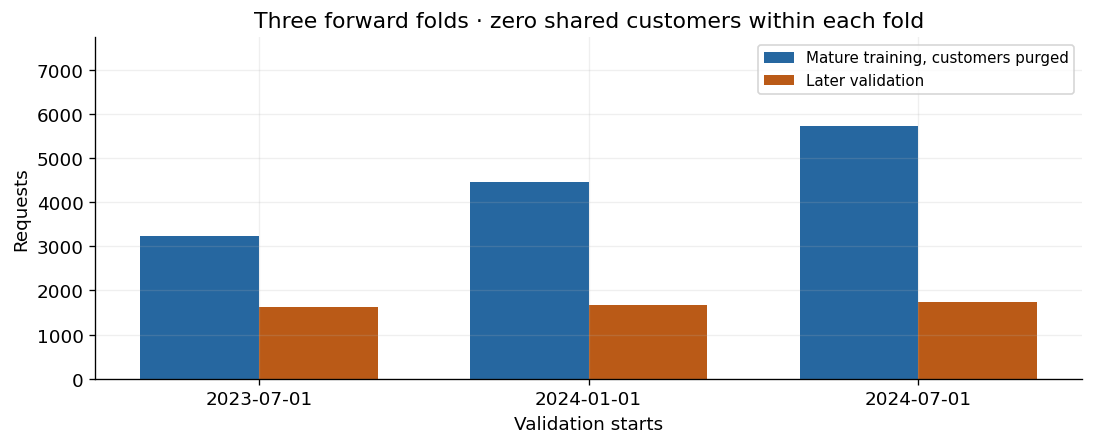

In [14]:
folds = make_time_group_split(clean, horizon_days=contract["target"]["horizon_days"])
fold_audit = pd.DataFrame([fold["audit"] for fold in folds])
for fold in folds:
    tr, va = clean.loc[fold["train"]], clean.loc[fold["valid"]]
    assert not set(tr.customer_id) & set(va.customer_id)
    assert (pd.to_datetime(tr.application_date) + pd.Timedelta(days=90) <
            pd.Timestamp(fold["audit"]["validation_start"])).all()
fold_audit["validation_positive_rate"] = fold_audit.validation_positives / fold_audit.validation_rows
display(fold_audit)

plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})
fig, ax = plt.subplots(figsize=(9, 3.6), constrained_layout=True)
x = np.arange(len(fold_audit))
ax.bar(x - .18, fold_audit.train_rows, .36, label="Mature training, customers purged", color="#2667A0")
ax.bar(x + .18, fold_audit.validation_rows, .36, label="Later validation", color="#BA5A17")
ax.set(xticks=x, xticklabels=fold_audit.validation_start, ylabel="Requests", xlabel="Validation starts",
       title="Three forward folds · zero shared customers within each fold")
ax.set_ylim(0, fold_audit.train_rows.max() * 1.35)
ax.legend(fontsize=9)
fig.savefig(ARTIFACTS / "day2_fold_sizes.png", dpi=160)
plt.show()

In [15]:
pool = reserve_tuning_pool(clean, folds)
outer_ids = np.concatenate([fold["valid"] for fold in folds])
assert not set(pool.customer_id) & set(clean.loc[outer_ids, "customer_id"])
assert (pd.to_datetime(pool.application_date) + pd.Timedelta(days=90) < pd.Timestamp("2023-07-01")).all()
display(pd.DataFrame([{"search_rows": len(pool), "search_positives": int(pool[target].sum()),
    "search_positive_rate": pool[target].mean(), "latest_application": pool.application_date.max(),
    "outer_validation_rows": len(outer_ids)}]))

,search_rows,search_positives,search_positive_rate,latest_application,outer_validation_rows
0,1935,176,0.090956,2023-04-01,5039


,status,completed_trials,attempted_trials,elapsed_seconds,stopping_reason,best_tuning_ap
0,COMPLETE,8,8,1.29009,TRIAL_LIMIT,0.333269


,fold,validation_start,validation_end_exclusive,train_rows,validation_rows,train_positives,validation_positives,immature_past_rows_removed,customer_overlap_rows_removed,shared_customers,latest_training_label_available
0,1,2022-10-01,2023-01-01,703,381,52,42,351,99,0,2022-09-30
1,2,2023-01-01,2023-03-01,1070,271,83,27,373,91,0,2022-12-31
2,3,2023-03-01,2023-04-02,1355,130,118,15,389,61,0,2023-02-28


,trial,state,mean_ap,seconds,learning_rate,num_leaves,min_child_samples,fold_1_ap,fold_2_ap,fold_3_ap
0,0,COMPLETE,0.316524,0.144737,0.085161,15,10,0.319910,0.320935,0.308727
1,1,COMPLETE,0.333269,0.136904,0.085305,31,40,0.391154,0.349373,0.259279
2,2,COMPLETE,0.308752,0.179292,0.034906,31,40,0.404534,0.271448,0.250276
3,3,COMPLETE,0.320550,0.185275,0.040259,31,20,0.384913,0.316815,0.259923
4,4,COMPLETE,0.327798,0.158959,0.062862,15,40,0.403532,0.310814,0.269049
5,5,COMPLETE,0.319093,0.160665,0.037608,7,10,0.365309,0.299275,0.292694
6,6,COMPLETE,0.318537,0.157793,0.039240,15,40,0.414490,0.284021,0.257101
7,7,COMPLETE,0.319024,0.148360,0.062020,31,20,0.376677,0.322038,0.258357


Frozen search parameters: {'learning_rate': 0.08530488562858765, 'num_leaves': 31, 'min_child_samples': 40}


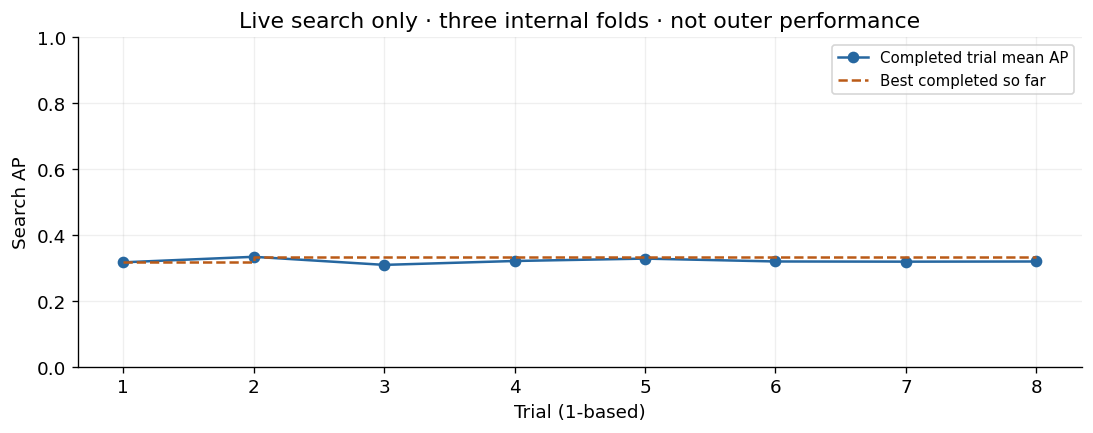

In [16]:
search, history = tune_on_reserved_pool(pool, contract, config)
has_tuned = search["best_params"] is not None
display(pd.DataFrame([{key: search[key] for key in ["status", "completed_trials", "attempted_trials",
    "elapsed_seconds", "stopping_reason", "best_tuning_ap"]}]))
display(pd.DataFrame(search["fold_audits"]))
display(history)
if not has_tuned:
    example = pd.read_csv(ROOT / "data/day2_optuna_example.csv")
    example_info = json.loads((ROOT / "data/day2_optuna_example.json").read_text(encoding="utf-8"))
    assert example_info["source"] == "EDUCATIONAL_EXAMPLE"
    print("EDUCATIONAL_EXAMPLE — discussion only; not your run or submission. TUNING_REQUIRED.")
    display(example)
else:
    print("Frozen search parameters:", search["best_params"])

fig, ax = plt.subplots(figsize=(9, 3.5), constrained_layout=True)
completed = history[history.state.eq("COMPLETE")]
if len(completed):
    ax.plot(completed.trial + 1, completed.mean_ap, marker="o", color="#2667A0", label="Completed trial mean AP")
    ax.step(completed.trial + 1, completed.mean_ap.cummax(), where="post", color="#BA5A17",
            linestyle="--", label="Best completed so far")
    ax.legend(fontsize=9)
else:
    ax.text(.5, .5, "No completed live trials — rerun needed", transform=ax.transAxes, ha="center")
ax.set(xlabel="Trial (1-based)", ylabel="Search AP", ylim=(0, 1), xticks=range(1, config.trials+1),
       title="Live search only · three internal folds · not outer performance")
fig.savefig(ARTIFACTS / "day2_search.png", dpi=160)
plt.show()

In [17]:
controls = negative_controls(clean, dirty, contract, config)
fixed_report, fixed_oof, fixed_origin = evaluate_outer(
    clean, contract, folds, BASE_PARAMS, config, "clean_time_group_fixed", fixed_trees=80)
reports, predictions, origins = [controls, fixed_report], [fixed_oof], fixed_origin
if has_tuned:
    tuned_report, tuned_oof, tuned_origin = evaluate_outer(
        clean, contract, folds, search["best_params"], config, "clean_time_group_tuned")
    reports.append(tuned_report); predictions.append(tuned_oof); origins += tuned_origin
validation_report = pd.concat(reports, ignore_index=True)
summary = summarize_folds(validation_report)
oof = pd.concat(predictions, ignore_index=True)
assert not oof.duplicated(["scheme", "application_id"]).any()
display(summary.round(4))
display(validation_report[["scheme", "fold", "roc_auc", "average_precision", "train_rows",
    "validation_rows", "selected_trees", "shared_customers", "prediction_source"]].round(4))
gaps = summary.set_index("scheme")
print("Observed AP gap, leaky minus clean random:",
      round(gaps.loc["leaky_random_control", "ap_mean"] - gaps.loc["clean_random_control", "ap_mean"], 4))
print("Observed AP gap, clean random minus honest fixed:",
      round(gaps.loc["clean_random_control", "ap_mean"] - gaps.loc["clean_time_group_fixed", "ap_mean"], 4))

,scheme,folds,validation_rows,roc_auc_mean,roc_auc_sd,ap_mean,ap_sd
0,leaky_random_control,3,10000,0.9999,0.0002,0.9988,0.0014
1,clean_random_control,3,10000,0.8010,0.0200,0.3110,0.0293
2,clean_time_group_fixed,3,5039,0.7976,0.0206,0.3153,0.0426
3,clean_time_group_tuned,3,5039,0.7855,0.0232,0.3133,0.0259


,scheme,fold,roc_auc,average_precision,train_rows,validation_rows,selected_trees,shared_customers,prediction_source
0,leaky_random_control,1,0.9996,0.9973,6666,3334,80,1713,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
1,clean_random_control,1,0.7807,0.2776,6666,3334,80,1713,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
2,leaky_random_control,2,0.9999,0.9992,6667,3333,80,1675,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
3,clean_random_control,2,0.8018,0.3232,6667,3333,80,1675,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
4,leaky_random_control,3,1.0000,1.0000,6667,3333,80,1656,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
5,clean_random_control,3,0.8206,0.3321,6667,3333,80,1656,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
6,clean_time_group_fixed,1,0.7948,0.3395,3223,1632,80,0,LIVE_OUT_OF_FOLD
7,clean_time_group_fixed,2,0.8194,0.3403,4460,1674,80,0,LIVE_OUT_OF_FOLD
8,clean_time_group_fixed,3,0.7786,0.2661,5731,1733,80,0,LIVE_OUT_OF_FOLD
9,clean_time_group_tuned,1,0.7826,0.3356,3223,1632,24,0,LIVE_OUT_OF_FOLD


Observed AP gap, leaky minus clean random: 0.6879
Observed AP gap, clean random minus honest fixed: -0.0044


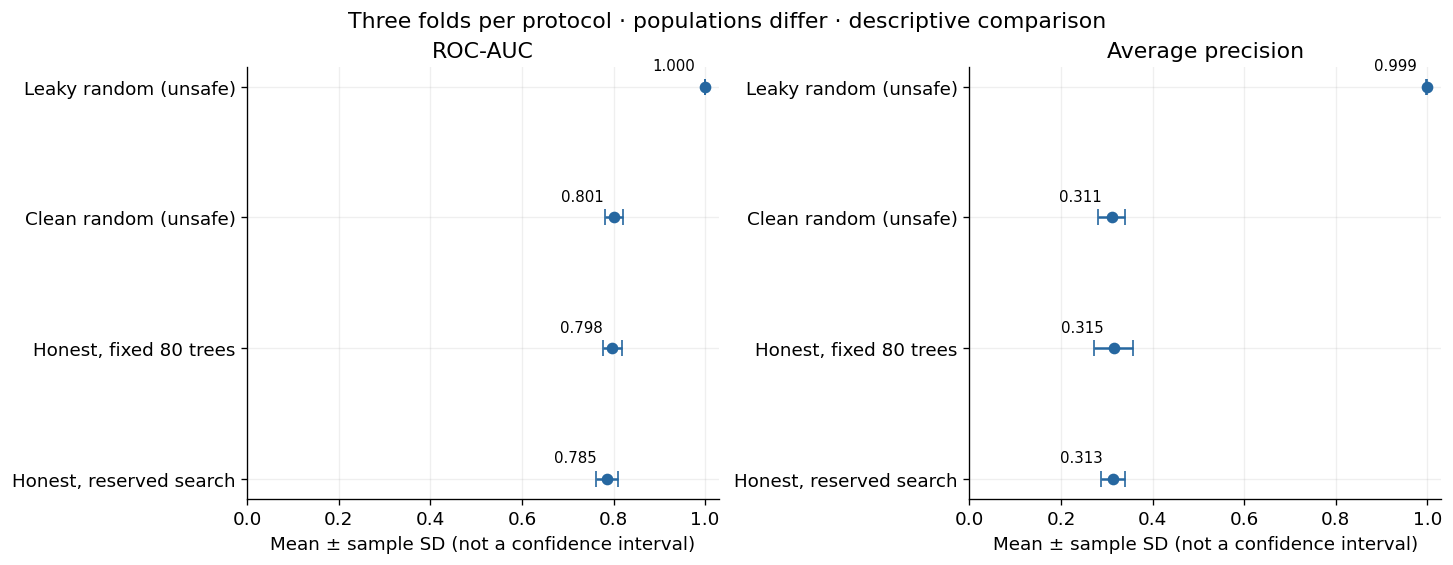

In [18]:
labels = {"leaky_random_control": "Leaky random (unsafe)", "clean_random_control": "Clean random (unsafe)",
          "clean_time_group_fixed": "Honest, fixed 80 trees", "clean_time_group_tuned": "Honest, reserved search"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
y = np.arange(len(summary))
for ax, mean_col, sd_col, title in zip(axes, ["roc_auc_mean", "ap_mean"], ["roc_auc_sd", "ap_sd"], ["ROC-AUC", "Average precision"]):
    ax.errorbar(summary[mean_col], y, xerr=summary[sd_col], fmt="o", capsize=5, color="#2667A0")
    ax.set(yticks=y, yticklabels=[labels[s] for s in summary.scheme], xlim=(0, 1.03),
           xlabel="Mean ± sample SD (not a confidence interval)", title=title)
    ax.invert_yaxis()
    for row, value in enumerate(summary[mean_col]):
        ax.annotate(f"{value:.3f}", (value, row), xytext=(-6, 10), textcoords="offset points", ha="right", fontsize=9)
fig.suptitle("Three folds per protocol · populations differ · descriptive comparison")
fig.savefig(ARTIFACTS / "day2_validation_comparison.png", dpi=160)
plt.show()

In [20]:
coverage = clean[["application_id", "application_date"]].copy()
coverage["role"], coverage["fold"] = "warmup_no_oof", 0
for fold in folds:
    coverage.loc[fold["valid"], "role"] = "eligible_oof"
    coverage.loc[fold["valid"], "fold"] = fold["audit"]["fold"]
eligible_ids = set(coverage.loc[coverage.role.eq("eligible_oof"), "application_id"])
for scheme, group in oof.groupby("scheme"):
    assert set(group.application_id) == eligible_ids
    assert group.probability.between(0, 1).all()
display(pd.DataFrame([{"all_rows": len(clean), "eligible_rows": len(eligible_ids),
    "warmup_without_oof": len(clean)-len(eligible_ids), "whole_data_coverage": len(eligible_ids)/len(clean),
    "eligible_coverage": 1.0, "live_honest_schemes": oof.scheme.nunique()}]))

,all_rows,eligible_rows,warmup_without_oof,whole_data_coverage,eligible_coverage,live_honest_schemes
0,10000,5039,4961,0.5039,1.0,2


In [21]:
responses = {
    "leak_example": "days_past_due_60 is a leaked field: it only exists after the loan is active and the customer misses payments, so it is not available at application time.",
    "split_reason": "We train on earlier periods and validate on later ones, like real use. Each customer stays on one side only (0 shared customers), and training uses only labels at least 90 days old so the outcome is truly known.",
    "observed_gap": "Leaky minus clean random AP was +0.688, and clean random minus honest fixed AP was -0.004. These come from 3 related time folds of one synthetic dataset, so they describe this run only and do not prove universal superiority.",
    "imputer_reason": "Imputation is learned inside each training fold so validation values never influence it. The inner stopping set only chooses the number of trees and is never used to report the final score.",
    "limitations": "Search budget: only 8 trials on 1,935 rows with 176 defaults, so the chosen parameters may be unstable (tuned AP 0.313 was not better than fixed 0.315). OOF covers only 50.39% of rows, and the 3 folds are related time periods, not independent samples."
}
checkpoint = reflection_check(responses)
print(checkpoint["status"])
print("Missing:", checkpoint["missing"])

READY_FOR_REVIEW
Missing: []


In [22]:
checkpoint = reflection_check(responses)
technical_status = "TECHNICAL_READY" if has_tuned else "TUNING_REQUIRED"
csv_outputs = {"validation_report.csv": validation_report, "validation_summary.csv": summary,
    "optuna_results.csv": history, "leakage_audit.csv": audit, "fold_audit.csv": fold_audit,
    "day2_oof_predictions.csv": oof, "day2_oof_coverage.csv": coverage}
for filename, table in csv_outputs.items():
    table.to_csv(ARTIFACTS / filename, index=False)
run = {"technical_status": technical_status, "learner_status": checkpoint["status"],
    "data_revision": COURSE_REVISION, "lab_revision": LAB_REVISION, "support_sha256": SUPPORT_HASHES,
    "data_manifest_sha256": MANIFEST_SHA256,
    "dirty_data_sha256": hashlib.sha256((ROOT / "data/tamweel_dirty.csv").read_bytes()).hexdigest(),
    "config": asdict(config), "mode": "FAST" if FAST_MODE else "FULL", "python": platform.python_version(),
    "duplicates": duplicates, "removed_features": leaked_features,
    "oof_rows_per_scheme": {name: len(group) for name, group in oof.groupby("scheme")},
    "oof_whole_data_coverage": len(eligible_ids)/len(clean), "warmup_rows": len(clean)-len(eligible_ids),
    "search_source": "LIVE", "example_used_for_results": False,
    "challenge_used_for_modeling": False, "grading": "No automatic grade"}
json_outputs = {"best_params.json": search, "day2_provenance.json": origins,
                "day2_reflection.json": {"responses": responses, "checkpoint": checkpoint}, "day2_run.json": run}
for filename, payload in json_outputs.items():
    (ARTIFACTS / filename).write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
files = list(csv_outputs) + list(json_outputs) + ["day2_fold_sizes.png", "day2_search.png",
    "day2_validation_comparison.png", "environment.json"]
with zipfile.ZipFile(ARTIFACTS / "day2_artifacts.zip", "w", zipfile.ZIP_DEFLATED) as archive:
    for filename in files:
        assert (ARTIFACTS / filename).is_file(), filename
        archive.write(ARTIFACTS / filename, arcname=filename)
print(technical_status, "|", checkpoint["status"])
print(f"Saved {len(files)} files in day2_artifacts.zip | احفظ الدفتر وملفاتك ثم أكمل تفسيرك")

TECHNICAL_READY | READY_FOR_REVIEW
Saved 15 files in day2_artifacts.zip | احفظ الدفتر وملفاتك ثم أكمل تفسيرك
